Задача 1

In [1]:
import os
import csv
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from tokenizers import Tokenizer, models, trainers
from tokenizers.normalizers import NFKC
from tokenizers.pre_tokenizers import Whitespace, Sequence


In [2]:
def load_lenta_texts(path, limit=None):
    texts = []
    with open(path, encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for i, row in enumerate(reader):
            texts.append(row["text"])
            if limit and i >= limit:
                break
    return texts

def load_pushkin_texts(folder):
    texts = []
    for fname in os.listdir(folder):
        if fname.endswith(".txt"):
            with open(os.path.join(folder, fname), encoding="utf-8") as f:
                texts.append(f.read())
    return texts

In [3]:
def train_bpe(corpus_file, vocab_size):
    from tokenizers import Tokenizer, models, trainers
    from tokenizers.normalizers import NFKC
    from tokenizers.pre_tokenizers import Whitespace, Sequence

    tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
    tokenizer.normalizer = NFKC()
    tokenizer.pre_tokenizer = Sequence([Whitespace()])

    trainer = trainers.BpeTrainer(
        vocab_size=vocab_size,
        special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"]
    )

    tokenizer.train([corpus_file], trainer)

    tokenizer.save("tokenizer.json")

    return tokenizer


def compression_ratio(tokenizer, text):
    return len(tokenizer.encode(text).ids) / len(text)


def tokens_per_word(tokenizer, text):
    words = text.split()
    if not words:
        return 0
    return len(tokenizer.encode(text).ids) / len(words)

In [138]:

lenta_texts = load_lenta_texts("lenta-ru-news.csv", limit=20_000)
pushkin_texts = load_pushkin_texts("texts")

print(f"Lenta texts: {len(lenta_texts)}")
print(f"Pushkin texts: {len(pushkin_texts)}")

with open("train_corpus.txt", "w", encoding="utf-8") as f:
    for t in lenta_texts:
        f.write(t.replace("\n", " ") + "\n")

lenta_eval = " ".join(lenta_texts[:1000])
pushkin_eval = " ".join(pushkin_texts)


Lenta texts: 739351
Pushkin texts: 913


In [5]:
vocab_size = 30000
tokenizer = train_bpe("train_corpus.txt", vocab_size)

print("\n=== Compression ratio ===")
print("Lenta:", compression_ratio(tokenizer, lenta_eval))
print("Pushkin:", compression_ratio(tokenizer, pushkin_eval))

print("\n=== Avg tokens per word ===")
print("Lenta:", tokens_per_word(tokenizer, lenta_eval))
print("Pushkin:", tokens_per_word(tokenizer, pushkin_eval))


=== Compression ratio ===
Lenta: 0.19881033947251395
Pushkin: 0.31928402782209175

=== Avg tokens per word ===
Lenta: 1.461250870941977
Pushkin: 1.9734118716293267


In [13]:
words = re.findall(r"\w+", " ".join(lenta_texts).lower())
word_freq = Counter(words)
top_10_percent = set(
    w for w, _ in word_freq.most_common(int(0.1 * len(word_freq)))
)

top_tokens = [
    len(tokenizer.encode(w).ids) for w in top_10_percent
]

print("\n=== Avg tokens per TOP-10% frequent words ===")
print(np.mean(top_tokens))


=== Avg tokens per TOP-10% frequent words ===
1.9338165773715728


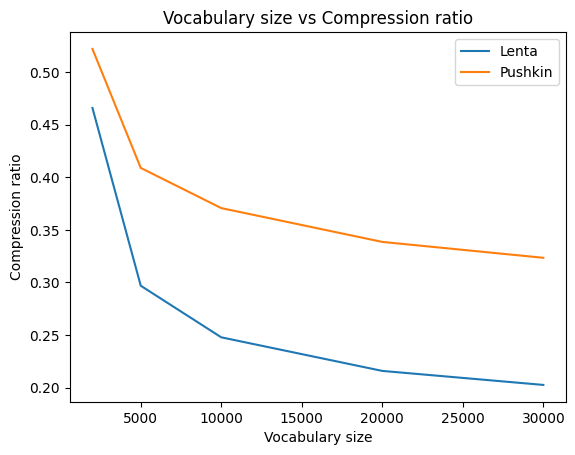

In [14]:
vocab_sizes = [2000, 5000, 10000, 20000, 30000]
lenta_ratios = []
pushkin_ratios = []

for vs in vocab_sizes:
    tok = train_bpe("train_corpus.txt", vs)
    lenta_ratios.append(compression_ratio(tok, lenta_eval))
    pushkin_ratios.append(compression_ratio(tok, pushkin_eval))

plt.plot(vocab_sizes, lenta_ratios, label="Lenta")
plt.plot(vocab_sizes, pushkin_ratios, label="Pushkin")
plt.xlabel("Vocabulary size")
plt.ylabel("Compression ratio")
plt.legend()
plt.title("Vocabulary size vs Compression ratio")
plt.show()

In [15]:
used_ids = set(tokenizer.encode(pushkin_eval).ids)
total_ids = set(range(tokenizer.get_vocab_size()))

unused_ratio = 1 - len(used_ids) / len(total_ids)

print("\n=== Unused tokens on Pushkin corpus ===")
print(f"{unused_ratio:.2%} of vocabulary unused")


=== Unused tokens on Pushkin corpus ===
69.67% of vocabulary unused


Задача 1.1.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [7]:
class LMDataset(Dataset):
    def __init__(self, token_ids, block_size):
        self.block_size = block_size
        self.data = token_ids

    def __len__(self):
        return max(0, len(self.data) - self.block_size)

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.block_size]
        y = self.data[idx+1:idx+self.block_size+1]
        return torch.tensor(x), torch.tensor(y)

In [8]:
class SimpleRNNLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hidden_dim=128):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        x = self.embed(x)
        out, _ = self.rnn(x)
        logits = self.fc(out)
        return logits

    def generate(self, tokenizer, start_text, max_length=50):
        self.eval()
        tokens = tokenizer.encode(start_text).ids
        tokens = torch.tensor(tokens).unsqueeze(0)
        device = next(self.parameters()).device
        tokens = tokens.to(device)
        generated = tokens[0].tolist()

        for _ in range(max_length):
            logits = self.forward(tokens)
            next_token = torch.argmax(logits[0, -1]).unsqueeze(0)
            generated.append(next_token.item())
            tokens = torch.cat([tokens, next_token.unsqueeze(0)], dim=1)

        return tokenizer.decode(generated)

In [9]:
def train_lm(model, loader, epochs=1):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)
    print("Training on device:", device)

    optimizer = torch.optim.Adam(model.parameters(), lr=5e-3)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits.view(-1, logits.size(-1)), y.view(-1))
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}: loss={total_loss/len(loader):.4f}")


In [33]:
if __name__ == "__main__":
    tokenizer = Tokenizer.from_file("tokenizer.json")

    with open("train_corpus.txt", encoding="utf-8") as f:
        text = f.read()[:500000]

    token_ids = tokenizer.encode(text).ids

    model = SimpleRNNLM(tokenizer.get_vocab_size(), emb_dim=64, hidden_dim=128)
    dataset = LMDataset(token_ids, block_size=16)
    loader = DataLoader(dataset, batch_size=16, shuffle=True)

    train_lm(model, loader, epochs=2)

    start_text = "В России"
    generated_text = model.generate(tokenizer, start_text, max_length=30)
    print("\n=== Generated text ===")
    print(generated_text)

Training on device: cuda
Epoch 1: loss=2.9943
Epoch 2: loss=1.3657

=== Generated text ===
В России препарат был зарегистрирован в конце 2015 года . Об этом заявил голливуд ский актер и спецпредставитель российского МИД на пресс - секретарь главы государства Свято слав Ц « Зимняя вишня


Задача 1.2.

In [6]:
from transformers import (
    GPT2LMHeadModel,
    GPT2TokenizerFast,
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling
)
from datasets import Dataset
from tokenizers import Tokenizer

c:\Users\Kostya\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\_param_validation.py:14: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.2)
  from scipy.sparse import csr_matrix, issparse


In [7]:
tokenizer_backend = Tokenizer.from_file("tokenizer.json")
tokenizer = GPT2TokenizerFast(tokenizer_object=tokenizer_backend)
tokenizer.pad_token = "<pad>"
tokenizer.eos_token = "<eos>"

In [8]:
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.resize_token_embeddings(len(tokenizer))

Embedding(30001, 768)

In [144]:
with open("train_corpus.txt", encoding="utf-8") as f:
    texts = f.readlines()[:10000]


dataset = Dataset.from_dict({"text": texts})

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True, remove_columns=["text"])

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

In [145]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

args = TrainingArguments(
    output_dir="./gpt2-custom-ru",
    per_device_train_batch_size=16,  
    num_train_epochs=2,
    learning_rate=5e-4,
    fp16=True,
    logging_steps=500,
    save_steps=1000,
    save_total_limit=2,
    report_to=None
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dataset,
    data_collator=data_collator
)

trainer.train()

Step,Training Loss
500,4.583600
1000,4.356700


TrainOutput(global_step=1250, training_loss=4.44029423828125, metrics={'train_runtime': 152.1446, 'train_samples_per_second': 131.454, 'train_steps_per_second': 8.216, 'total_flos': 1306460160000000.0, 'train_loss': 4.44029423828125, 'epoch': 2.0})

In [88]:
prompt = "В России"

device = model.device
inputs = tokenizer(prompt, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model.generate(
    **inputs,
    max_length=50,
    do_sample=True,
    top_k=50,
    top_p=0.95
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


В России удовлетворил ходатайство теракта , которое прошло в Керчи со стороны москвичей — это на видео . Об этом пишет сайт Cit ies . Ожидается о том , что « так много слой » будет от чая мой , но в соответствии с этим в то время как минимум


In [89]:
prompt = "В России"

device = model.device
inputs = tokenizer(prompt, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model.generate(
    **inputs,
    max_length=50,
    do_sample=True,
    top_k=50,
    top_p=0.95
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


В России стартовал « М АО » Ким Чен Ына с одной из четырех летней в интернете . Об этом сообщает издание The Daily Mail . Отмечается , что неизвестные похитили было вы водит за помощью « М АО » в интернете . По утверждению источника , на свою очередь


In [143]:
prompt = "В России"

device = model.device
inputs = tokenizer(prompt, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model.generate(
    **inputs,
    max_length=100,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    temperature=0.8
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


В России в четверг , 1 апреля , в рамках нового президента России , которые подозреваются в России , а в качестве основной показатель за последние несколько месяцев . Об этом в четверг , 10 апреля , заявил , что в случае реализации этого момента начала войны . По его словам , на его взгляд , в последнее время в прошлом году в России в России , а также и на год , в частности , на место событий . При этом , по словам экспертов , это время , в том числе и на уровне 30 процентов в России


In [165]:
prompt = "В России"

device = model.device
inputs = tokenizer(prompt, return_tensors="pt")
inputs = {k: v.to(device) for k, v in inputs.items()}

outputs = model.generate(
    **inputs,
    max_length=100,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    temperature=0.8
)

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


В России задержаны два человека погибли , еще трое получили травмы , передает « Комсомольская правда » со ссылкой на данные Главного штаба . Инцидент произошел в городе Си ге на в селе Из - за границы с участниками трех метровой высоты . « С учетом того , что двое человека погибли , а человека получили ранения . С учетом этого человека погибли . Еще семь человек получили ранения . « Еще один человек погиб , когда человека получили от них погибли », — сказал в региональном управлении регионального управления ФСБ . По словам очевидцев , были отправлены в районе
